# ezmerce v2 백엔드 — 테스트 & 라이브 워크스루

이 노트북은 1차 백엔드의 **각 기능을 실제로 실행**해 보고, 동시에 **해당 pytest를 직접 돌려** 결과를 보여줍니다.

- 커널: **ezmerce v2 (.venv)** 를 선택하세요 (backend/.venv).
- 위에서부터 순서대로 실행하면 됩니다. 셀마다 `라이브 데모` + `pytest 실행`이 함께 들어 있습니다.

| 영역 | 데모 | 테스트 파일 |
|---|---|---|
| 품번 정규화 | platform_code 포맷 | test_platform_code.py |
| 가격 차등 노출 | 역할×유형 매트릭스 | test_pricing.py |
| 엑셀 파서 | 샘플 xlsx 파싱 | test_excel_parse.py |
| 이미지 매칭 | 파일명→품번 | test_image_match.py |
| QR | 이미지 직접 렌더 | test_qr.py |
| 엑셀 출력 | QR 삽입 xlsx | test_excel_export.py |
| 인증/RBAC | 권한 가드 | test_auth_dep.py / test_rbac.py |
| 카탈로그 | 역할별 셰이핑 | test_catalog_shaping.py |
| FastAPI 앱 | /health + 라우트 | test_health.py |


## 0. 환경 셋업
`backend/`를 작업 경로로 잡고 `app` 패키지를 import 가능하게 합니다.

In [1]:
from pathlib import Path
import os, sys

here = Path.cwd()
BACKEND = here if (here / "app").exists() else (here.parent if (here.parent / "app").exists() else here)
os.chdir(BACKEND)
sys.path.insert(0, str(BACKEND))
print("backend :", BACKEND)
print("python  :", sys.version.split()[0])

import subprocess

def run_pytest(*files, q=False):
    """해당 테스트 파일을 실제로 실행하고 출력을 보여준다."""
    cmd = [sys.executable, "-m", "pytest", *files, "-v" if not q else "-q", "--no-header"]
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout[-3500:])
    if r.returncode != 0:
        print("STDERR:", r.stderr[-1500:])
    return r.returncode

backend : /Users/goldenplanet/jinsup_space/autoproducts/backend
python  : 3.12.11


## 1. 전체 테스트 한 번에 (26 cases)
외부 Supabase 없이 fake repo로 전부 돌아갑니다.

In [2]:
run_pytest(q=True)

..........................                                               [100%]
=============================== warnings summary ===============================
app/core/config.py:5
  /Users/goldenplanet/jinsup_space/autoproducts/backend/app/core/config.py:5: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
    class Settings(BaseSettings):

.venv/lib/python3.12/site-packages/fastapi/testclient.py:1
  /Users/goldenplanet/jinsup_space/autoproducts/backend/.venv/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
    from starlette.testclient import TestClient as TestClient  # noqa

backend/tests/test_auth_dep.py::test_decode_valid_jwt
  /Users/goldenplanet/jinsup_space/autoproducts/backend/.venv/li

0

## 2. 품번 정규화 — `platform_code`
여러 도매업체 상품이 섞여도 충돌하지 않도록 플랫폼이 글로벌 식별자를 발급합니다.

In [3]:
from app.services.platform_code import format_platform_code

for seq in (1, 42, 123456, 12345678):
    print(format_platform_code(seq, prefix="EZM"))

print("\n--- pytest ---")
run_pytest("tests/test_platform_code.py")

EZM-000001
EZM-000042
EZM-123456
EZM-12345678

--- pytest ---
============================= test session starts ==============================
collecting ... collected 2 items

tests/test_platform_code.py::test_format_zero_pads_with_prefix PASSED    [ 50%]
tests/test_platform_code.py::test_format_overflow_keeps_full_number PASSED [100%]

============================== 2 passed in 0.00s ===============================



0

## 3. 가격 차등 노출 렌즈 (FR-5.2)
같은 SKU라도 **보는 역할에 따라 다른 가격**이 나갑니다. 서버에서 결정(클라이언트 신뢰 X).

In [4]:
import pandas as pd
from app.services.pricing import visible_price

SKU = {"wholesale_price": 12000, "retail_price": 29000, "product_org": "org-1"}
cases = [
    ("retail_seller", "independent", "org-1"),
    ("retail_seller", "agency_affiliated", "org-1"),
    ("agency", None, None),
    ("wholesaler", None, "org-1"),
    ("admin", None, None),
    ("guest", None, None),
]
rows = [{"role": r, "seller_type": st, "노출 결과": visible_price(r, st, SKU, viewer_org=o)} for r, st, o in cases]
display(pd.DataFrame(rows))

print("--- pytest ---")
run_pytest("tests/test_pricing.py")

,role,seller_type,노출 결과
0,retail_seller,independent,{'price': 12000}
1,retail_seller,agency_affiliated,{'price': None}
2,agency,NaN,{'price': 29000}
3,wholesaler,NaN,"{'wholesale_price': 12000, 'retail_price': 29000}"
4,admin,NaN,"{'wholesale_price': 12000, 'retail_price': 29000}"
5,guest,NaN,{'price': None}


--- pytest ---
============================= test session starts ==============================
collecting ... collected 5 items

tests/test_pricing.py::test_independent_seller_sees_wholesale PASSED     [ 20%]
tests/test_pricing.py::test_agency_affiliated_seller_sees_none PASSED    [ 40%]
tests/test_pricing.py::test_agency_sees_retail PASSED                    [ 60%]
tests/test_pricing.py::test_wholesaler_owner_sees_both PASSED            [ 80%]
tests/test_pricing.py::test_unknown_role_gets_none PASSED                [100%]

============================== 5 passed in 0.00s ===============================



0

## 4. 표준 엑셀 템플릿 파서 (FR-2.2)
표준 양식을 파싱하고, 도매가 누락 같은 불량 행은 에러로 분리해 수작업 매칭으로 넘깁니다.

In [5]:
import openpyxl, tempfile, os, pandas as pd
from app.services.excel_parse import parse_template_rows, TEMPLATE_COLUMNS

wb = openpyxl.Workbook(); ws = wb.active
ws.append(TEMPLATE_COLUMNS)
ws.append(["1001", "린넨 셔츠", "화이트", "F", "12000", "29000"])
ws.append(["1002", "와이드 팬츠", "블랙", "L", "", "20000"])   # 도매가 누락 → error
p = os.path.join(tempfile.mkdtemp(), "sample.xlsx"); wb.save(p)

res = parse_template_rows(p)
print("정상 행:"); display(pd.DataFrame(res.rows))
print("에러 행:"); display(pd.DataFrame(res.errors))

print("--- pytest ---")
run_pytest("tests/test_excel_parse.py")

정상 행:


,source_p_number,item_name,color,size,wholesale_price,retail_price
0,1001,린넨 셔츠,화이트,F,12000,29000


에러 행:


,row,reason,raw
0,3,"int() argument must be a string, a bytes-like ...","[1002, 와이드 팬츠, 블랙, L, None, 20000]"


--- pytest ---


============================= test session starts ==============================
collecting ... collected 2 items

tests/test_excel_parse.py::test_parse_valid_rows PASSED                  [ 50%]
tests/test_excel_parse.py::test_parse_missing_price_is_error PASSED      [100%]

============================== 2 passed in 0.06s ===============================



0

## 5. 이미지 자동 매칭 (FR-2.3)
업로드 이미지 파일명에서 품번 토큰을 뽑아 상품과 자동 연결합니다.

In [6]:
from app.services.image_match import match_filename_to_product

products = {"1001": "product-A", "1002": "product-B"}
for fn in ["1001.jpg", "1001_main.png", "1002-01.jpeg", "zzz.png"]:
    print(f"{fn:16} -> {match_filename_to_product(fn, products)}")

print("\n--- pytest ---")
run_pytest("tests/test_image_match.py")

1001.jpg         -> product-A
1001_main.png    -> product-A
1002-01.jpeg     -> product-B
zzz.png          -> None

--- pytest ---


============================= test session starts ==============================
collecting ... collected 2 items

tests/test_image_match.py::test_match_by_source_p_number PASSED          [ 50%]
tests/test_image_match.py::test_no_match_returns_none PASSED             [100%]

============================== 2 passed in 0.00s ===============================



0

## 6. QR 코드 생성 (FR-4) — 이미지 직접 보기
QR이 가리키는 공개 카드 URL과 실제 QR PNG를 인라인으로 렌더링합니다.

QR 대상 URL: https://shop.ezmerce.io/p/EZM-000001
PNG bytes: 807 | 시그니처 OK: True


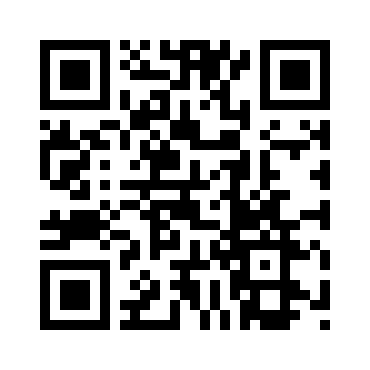

--- pytest ---


============================= test session starts ==============================
collecting ... collected 2 items

tests/test_qr.py::test_qr_target_url PASSED                              [ 50%]
tests/test_qr.py::test_generate_qr_png_returns_png_bytes PASSED          [100%]

============================== 2 passed in 0.02s ===============================



0

In [7]:
from app.services.qr import qr_target_url, generate_qr_png
from IPython.display import Image, display

url = qr_target_url("EZM-000001", "https://shop.ezmerce.io")
print("QR 대상 URL:", url)
png = generate_qr_png(url)
print("PNG bytes:", len(png), "| 시그니처 OK:", png[:8] == b"\x89PNG\r\n\x1a\n")
display(Image(data=png))

print("--- pytest ---")
run_pytest("tests/test_qr.py")

## 7. 엑셀 출력 + QR 삽입 (FR-3)
셀러용 카탈로그 엑셀의 **최우측 열에 QR 이미지가 자동 삽입**됩니다 (폼텍 라벨 대체).

In [8]:
import openpyxl, tempfile, os
from app.services.excel_export import build_catalog_xlsx

items = [
    {"platform_code": "EZM-000001", "item_name": "린넨 셔츠", "price": 12000},
    {"platform_code": "EZM-000002", "item_name": "와이드 팬츠", "price": 18000},
]
out = os.path.join(tempfile.mkdtemp(), "catalog.xlsx")
build_catalog_xlsx(items, out, base_url="https://shop.ezmerce.io")

wb = openpyxl.load_workbook(out); ws = wb.active
print("헤더:", [c.value for c in ws[1]], "  (최우측 =", [c.value for c in ws[1]][-1], ")")
print("삽입된 QR 이미지 개수:", len(ws._images))
print("저장 위치:", out)

print("--- pytest ---")
run_pytest("tests/test_excel_export.py")

헤더: ['품번', '상품명', '가격', 'QR']   (최우측 = QR )
삽입된 QR 이미지 개수: 2
저장 위치: /tmp/claude-501/tmpbz7dopx8/catalog.xlsx
--- pytest ---


============================= test session starts ==============================
collecting ... collected 1 item

tests/test_excel_export.py::test_export_has_qr_column_last PASSED        [100%]

============================== 1 passed in 0.07s ===============================



0

## 8. 인증 / RBAC (FR-1)
역할/승인 가드가 허용·차단을 올바로 수행하는지 직접 호출해 봅니다.

In [9]:
from app.core.rbac import require_role, require_approved
from app.schemas.auth import CurrentUser

u = CurrentUser(id="u1", role="wholesaler", status="approved")
print("wholesaler -> wholesaler 권한:", require_role("wholesaler")(u).role, "(통과)")

try:
    require_role("admin")(u)
except Exception as e:
    print("wholesaler -> admin 시도:", type(e).__name__, getattr(e, "status_code", ""))

try:
    require_approved(CurrentUser(id="u2", role="agency", status="pending"))
except Exception as e:
    print("pending 계정 접근 시도:", type(e).__name__, getattr(e, "status_code", ""))

print("\n--- pytest ---")
run_pytest("tests/test_auth_dep.py", "tests/test_rbac.py")

wholesaler -> wholesaler 권한: wholesaler (통과)
wholesaler -> admin 시도: HTTPException 403
pending 계정 접근 시도: HTTPException 403

--- pytest ---


============================= test session starts ==============================
collecting ... collected 5 items

tests/test_auth_dep.py::test_decode_valid_jwt PASSED                     [ 20%]
tests/test_auth_dep.py::test_decode_invalid_jwt_raises PASSED            [ 40%]
tests/test_rbac.py::test_require_role_pass PASSED                        [ 60%]
tests/test_rbac.py::test_require_role_block PASSED                       [ 80%]
tests/test_rbac.py::test_require_approved_blocks_pending PASSED          [100%]

=============================== warnings summary ===============================
app/core/config.py:5
  /Users/goldenplanet/jinsup_space/autoproducts/backend/app/core/config.py:5: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
    class Settings(BaseSettings):

backend/tests/test_auth_dep.py::test_dec

0

## 9. 폐쇄형 카탈로그 셰이핑 (FR-5)
같은 카탈로그 행이 역할에 따라 어떻게 다르게 보이는지 확인합니다.

In [10]:
from app.routers.catalog import shape_catalog_item
from app.schemas.auth import CurrentUser

ROW = {"platform_code": "EZM-1", "item_name": "셔츠",
       "skus": [{"color": "화이트", "size": "F", "wholesale_price": 12000, "retail_price": 29000, "product_org": "org-9"}]}

for role, st in [("retail_seller", "independent"), ("retail_seller", "agency_affiliated"), ("agency", None)]:
    u = CurrentUser(id="u", role=role, status="approved", seller_type=st)
    item = shape_catalog_item(ROW, u)
    print(f"{role:14}/{str(st):18} -> {item['skus'][0]}")

print("\n--- pytest ---")
run_pytest("tests/test_catalog_shaping.py")

retail_seller /independent        -> {'color': '화이트', 'size': 'F', 'price': 12000}
retail_seller /agency_affiliated  -> {'color': '화이트', 'size': 'F', 'price': None}
agency        /None               -> {'color': '화이트', 'size': 'F', 'price': 29000}

--- pytest ---


============================= test session starts ==============================
collecting ... collected 2 items

tests/test_catalog_shaping.py::test_agency_affiliated_seller_item_has_no_price PASSED [ 50%]
tests/test_catalog_shaping.py::test_independent_seller_sees_wholesale PASSED [100%]

=============================== warnings summary ===============================
app/core/config.py:5
  /Users/goldenplanet/jinsup_space/autoproducts/backend/app/core/config.py:5: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
    class Settings(BaseSettings):

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
========================= 2 passed, 1 warning in 0.27s =========================



0

## 10. FastAPI 앱 — `/health` + 라우트 테이블
앱을 띄워 헬스체크하고 등록된 라우트를 확인합니다.

In [11]:
from fastapi.testclient import TestClient
from app.main import app

c = TestClient(app)
print("/health ->", c.get("/health").json())
print("\n등록된 라우트:")
for path in sorted({r.path for r in app.routes}):
    print("  ", path)

print("\n--- pytest ---")
run_pytest("tests/test_health.py")

/health -> {'status': 'ok'}

등록된 라우트:
   /admin/accounts
   /admin/accounts/{uid}/approve
   /admin/accounts/{uid}/reject
   /catalog
   /docs
   /docs/oauth2-redirect
   /health
   /openapi.json
   /p/{platform_code}
   /products
   /products/{pid}
   /qr/{platform_code}.png
   /redoc

--- pytest ---


/Users/goldenplanet/jinsup_space/autoproducts/backend/.venv/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


============================= test session starts ==============================
collecting ... collected 1 item

tests/test_health.py::test_health_ok PASSED                              [100%]

=============================== warnings summary ===============================
.venv/lib/python3.12/site-packages/fastapi/testclient.py:1
  /Users/goldenplanet/jinsup_space/autoproducts/backend/.venv/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
    from starlette.testclient import TestClient as TestClient  # noqa

app/core/config.py:5
  /Users/goldenplanet/jinsup_space/autoproducts/backend/app/core/config.py:5: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
    class Settings(BaseSettings):

-- 

0

---
✅ 여기까지 모두 통과하면 1차 백엔드 코어가 정상 동작하는 것입니다.

**아직 라우트가 없는 부분(로직은 구현됨):** 업로드 오케스트레이션(`/uploads/*`), `POST /auth/register`, `GET /catalog/export.xlsx`.
**런타임 연결:** Supabase에 `backend/migrations/2026-06-03_v2_core.sql` 적용 + `backend/.env`(SUPABASE_URL / SERVICE_KEY / JWT_SECRET).
